# Keith Wampler
# 569 Spring 2026
# Homework 4

Load the MNIST digits file
Build a classification model in PyTorch
    Include dropout
Estimate the number of learned parameters involved with the model
Tune the model’s learning rate
Send me your code and a couple of paragraphs describing any patterns in the performance and also a couple of paragraphs describing any tradeoffs in model complexity and model performance


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

torch.manual_seed(1701)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = 50000
val_size = 10000

trainset, valset = random_split(
    full_trainset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1701)
)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64, shuffle=False)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training batches: {len(trainloader)}")
print(f"Validation batches: {len(valloader)}")
print(f"Testing batches: {len(testloader)}")

dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Shape of the image batch: {images.shape}")
print(f"Shape of a single image: {images[0].shape}")


Training batches: 782
Validation batches: 157
Testing batches: 157
Shape of the image batch: torch.Size([64, 1, 28, 28])
Shape of a single image: torch.Size([1, 28, 28])


In [15]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

torch.manual_seed(1701)
model = Net()
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total learned parameters: {total_params:,}")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name} | Size: {param.size()} | Parameters: {param.numel():,}")


Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)
Total learned parameters: 109,386
Layer: fc1.weight | Size: torch.Size([128, 784]) | Parameters: 100,352
Layer: fc1.bias | Size: torch.Size([128]) | Parameters: 128
Layer: fc2.weight | Size: torch.Size([64, 128]) | Parameters: 8,192
Layer: fc2.bias | Size: torch.Size([64]) | Parameters: 64
Layer: fc3.weight | Size: torch.Size([10, 64]) | Parameters: 640
Layer: fc3.bias | Size: torch.Size([10]) | Parameters: 10


In [16]:
sweep_rates = [0.1, 0.01, 0.001, 0.0001]
sweep_epochs = 3
sweep_results = {}

for lr in sweep_rates:
    torch.manual_seed(1701)
    sweep_model = Net()
    sweep_optimizer = optim.Adam(sweep_model.parameters(), lr=lr)
    sweep_criterion = nn.CrossEntropyLoss()

    for epoch in range(sweep_epochs):
        sweep_model.train()
        for inputs, labels in trainloader:
            sweep_optimizer.zero_grad()
            outputs = sweep_model(inputs)
            loss = sweep_criterion(outputs, labels)
            loss.backward()
            sweep_optimizer.step()

    sweep_model.eval()
    correct = 0
    total = 0
    running_val_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in valloader:
            outputs = sweep_model(inputs)
            running_val_loss += sweep_criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_loss = running_val_loss / len(valloader)
    sweep_results[lr] = (val_loss, val_acc)
    print(f"LR {lr:<8} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

best_lr = min(sweep_results, key=lambda k: sweep_results[k][0])
print(f"\nBest learning rate by validation loss after {sweep_epochs} epochs: {best_lr}")


LR 0.1      | Val Loss: 2.3039 | Val Acc: 10.27%
LR 0.01     | Val Loss: 0.3659 | Val Acc: 89.97%
LR 0.001    | Val Loss: 0.1591 | Val Acc: 95.39%
LR 0.0001   | Val Loss: 0.2883 | Val Acc: 91.36%

Best learning rate by validation loss after 3 epochs: 0.001


In [17]:
torch.manual_seed(1701)
model = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

epochs = 20
patience = 4
patience_counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    avg_train_loss = running_train_loss / len(trainloader)
    train_acc = 100 * correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in valloader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = running_val_loss / len(valloader)
    val_acc = 100 * correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    learning_rates.append(optimizer.param_groups[0]['lr'])
    
    print(f'Epoch [{epoch + 1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_mnist_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at Epoch {epoch + 1}!")
            break


Epoch [1/20] | Train Loss: 0.5429 | Val Loss: 0.2609 | Val Acc: 91.95%
Epoch [2/20] | Train Loss: 0.2854 | Val Loss: 0.1971 | Val Acc: 93.98%
Epoch [3/20] | Train Loss: 0.2341 | Val Loss: 0.1549 | Val Acc: 95.56%
Epoch [4/20] | Train Loss: 0.2095 | Val Loss: 0.1430 | Val Acc: 95.81%
Epoch [5/20] | Train Loss: 0.1907 | Val Loss: 0.1231 | Val Acc: 96.30%
Epoch [6/20] | Train Loss: 0.1766 | Val Loss: 0.1304 | Val Acc: 96.03%
Epoch [7/20] | Train Loss: 0.1676 | Val Loss: 0.1174 | Val Acc: 96.51%
Epoch [8/20] | Train Loss: 0.1586 | Val Loss: 0.1115 | Val Acc: 96.79%
Epoch [9/20] | Train Loss: 0.1574 | Val Loss: 0.1123 | Val Acc: 96.53%
Epoch [10/20] | Train Loss: 0.1522 | Val Loss: 0.1075 | Val Acc: 96.75%
Epoch [11/20] | Train Loss: 0.1479 | Val Loss: 0.1093 | Val Acc: 96.55%
Epoch [12/20] | Train Loss: 0.1388 | Val Loss: 0.1047 | Val Acc: 97.02%
Epoch [13/20] | Train Loss: 0.1367 | Val Loss: 0.1056 | Val Acc: 96.95%
Epoch [14/20] | Train Loss: 0.1299 | Val Loss: 0.1006 | Val Acc: 97.08%
E

In [18]:
best_model = Net()
best_model.load_state_dict(torch.load('best_mnist_model.pth'))
best_model.eval()

test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in testloader:
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

avg_test_loss = test_loss / len(testloader)
test_acc = 100 * correct_test / total_test

print(f"Final Test Loss: {avg_test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.2f}%")

Final Test Loss: 0.0847
Final Test Accuracy: 97.53%


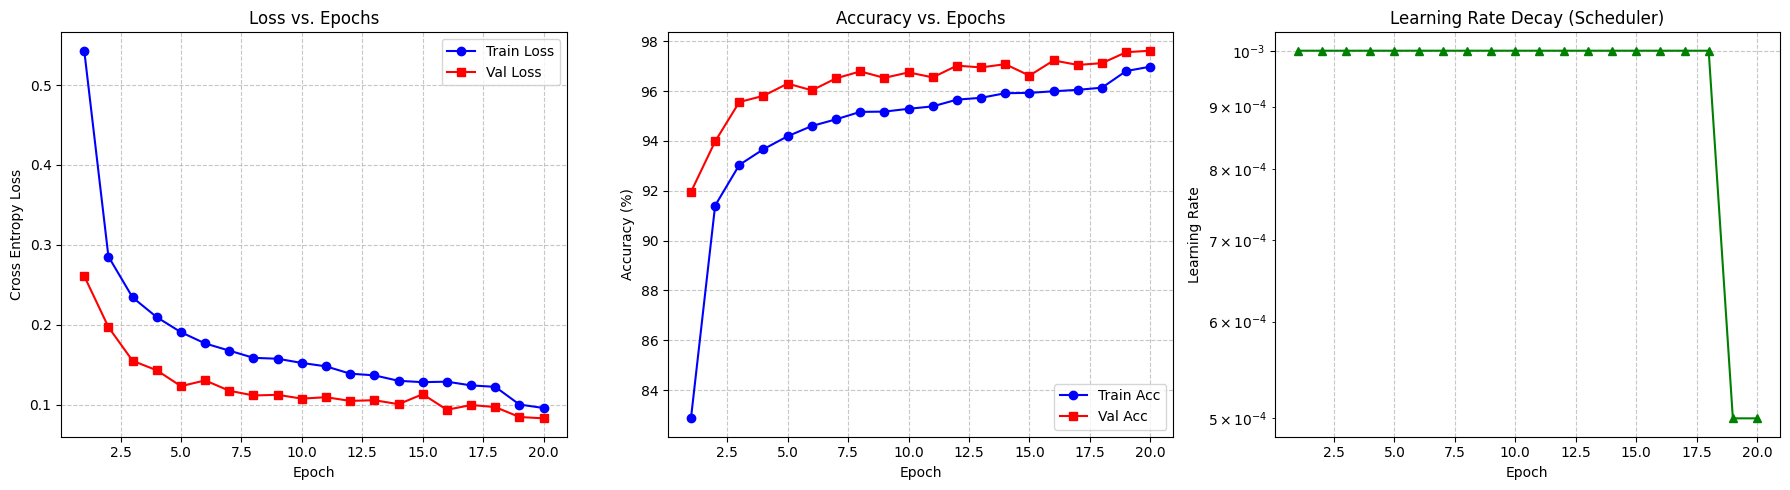

In [19]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss', color='red', marker='s')
ax1.set_title('Loss vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Acc', color='blue', marker='o')
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Val Acc', color='red', marker='s')
ax2.set_title('Accuracy vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

ax3.plot(range(1, len(learning_rates) + 1), learning_rates, color='green', marker='^')
ax3.set_title('Learning Rate Decay (Scheduler)')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log') 
ax3.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Patterns in Performance

The learning-rate sweep cleanly separates the candidate rates. At 0.1, the model effectively fails to learn, producing accuracy close to the no-information baseline of about 10 percent for ten classes and a cross-entropy loss near -ln(0.1) ≈ 2.3026. The 0.01 rate learns substantially better but appears less stable, while 0.0001 is stable but slower to converge within the short three-epoch sweep. The middle rate of 0.001 produces the best validation performance, so I use it for the full training run.

In the full run, training and validation performance improve quickly in the early epochs and then level off as the model makes smaller refinements. Some noise in validation loss is expected because the model uses mini-batches and dropout. Validation loss can also sit below training loss because dropout is active during training but turned off during evaluation, so the validation pass uses the full network. The scheduler reduces the learning rate after validation loss plateaus, allowing the optimizer to take smaller steps later in training. I use the validation-loss checkpoint for the final model, then evaluate that saved model once on the held-out test set.

### Complexity Tradeoffs

This architecture illustrates the need to balance model capacity and data dimensionality. At approximately 109,386 trainable parameters, this multilayer perceptron has enough capacity to learn useful nonlinear patterns in 28x28 grayscale digit images. Removing hidden layers would reduce the parameter count and computational cost, but it would also limit the network's ability to distinguish visually similar digits such as 3, 5, and 8.

I would not want to make this model much bigger just for MNIST. The images are small, and the task is simpler than many real-world image problems, so adding more layers or many more neurons might mostly add training time without a large improvement in accuracy. A convolutional neural network would probably be better for image data because it can pay attention to nearby pixels, while this model flattens each image into one long list of numbers. For this homework, though, the simpler MLP works well because it is easier to understand and still shows the effects of dropout, learning rate, and model size.
